# Credit Risk Stress Testing Engine — Analysis Walkthrough

This notebook walks through the end-to-end methodology exactly as implemented in
the `src/` package:

1. Load & validate a real public credit-risk dataset
2. Clean and profile the data
3. Train a Probability of Default (PD) model (+ compare & calibrate)
4. Evaluate with ranking **and** calibration metrics
5. Compute Expected Credit Loss (EL = PD × LGD × EAD)
6. Segment the portfolio into risk bands
7. Run hypothetical stress scenarios

> **Reminders:** Expected Loss is a forward-looking *statistical expectation*, not a
> realised loss. Stress scenarios are *hypothetical sensitivity analyses*, not
> forecasts. The LGD assumption and risk-band thresholds are transparent modelling
> choices, not regulatory standards.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

from src.data_loader import load_raw_data, profile_data
from src.preprocessing import clean_data, split_data

## 1–2. Load, validate, clean and profile

In [2]:
raw = load_raw_data()
print(profile_data(raw).summary())

Dataset profile (observed data)
-------------------------------
Observations      : 32,581
Columns           : 12
Default events    : 7,108
Default rate      : 21.82%
Numeric features  : 7
Categorical feats : 4
Missing values    :
    - person_emp_length: 895
    - loan_int_rate: 3,116


In [3]:
clean = clean_data(raw)
print(f'Rows: {len(raw):,} raw -> {len(clean):,} after removing implausible records')
clean.head()

Rows: 32,581 raw -> 32,574 after removing implausible records


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0000,EDUCATION,B,1000,11.1400,0,0.1000,N,2
1,25,9600,MORTGAGE,1.0000,MEDICAL,C,5500,12.8700,1,0.5700,N,3
2,23,65500,RENT,4.0000,MEDICAL,C,35000,15.2300,1,0.5300,N,2
3,24,54400,RENT,8.0000,MEDICAL,C,35000,14.2700,1,0.5500,Y,4
4,21,9900,OWN,2.0000,VENTURE,A,2500,7.1400,1,0.2500,N,2


### Train/test split (stratified on the imbalanced default target)
Preprocessing (imputation, scaling, one-hot encoding) happens *inside* the model
pipeline so statistics are learned from the training fold only — this prevents
leakage.

In [4]:
split = split_data(clean)
print(f'Train: {split.train_size:,}  |  Test: {split.test_size:,}')
print(f'Train default rate: {split.y_train.mean():.2%}  |  Test default rate: {split.y_test.mean():.2%}')

Train: 24,430  |  Test: 8,144
Train default rate: 21.82%  |  Test default rate: 21.82%


## 3–4. Train the PD model, compare and calibrate

In [5]:
from src.pd_model import train

model, report = train(split, compare_gbm=True, calibrate=True)
comp = pd.DataFrame({k: {m: v[m] for m in ['roc_auc','pr_auc','precision','recall','f1','brier_score']}
                     for k, v in report['models'].items()}).T
print('Chosen model:', report['chosen_model'])
comp

Chosen model: LogisticRegression (isotonic-calibrated)


,roc_auc,pr_auc,precision,recall,f1,brier_score
logistic_uncalibrated,0.8598,0.7028,0.5425,0.7541,0.6310,0.1408
gradient_boosting,0.9191,0.8643,0.9485,0.6939,0.8014,0.0662
logistic_calibrated,0.8597,0.6996,0.7284,0.5706,0.6399,0.1059


**Why calibration matters here:** PD feeds *directly* into Expected Loss
(EL = PD × LGD × EAD). A model can rank borrowers well (high ROC-AUC) yet produce
mis-scaled probabilities, which would bias every loss number. We therefore select
the variant with the lower **Brier score** (better-calibrated probabilities).

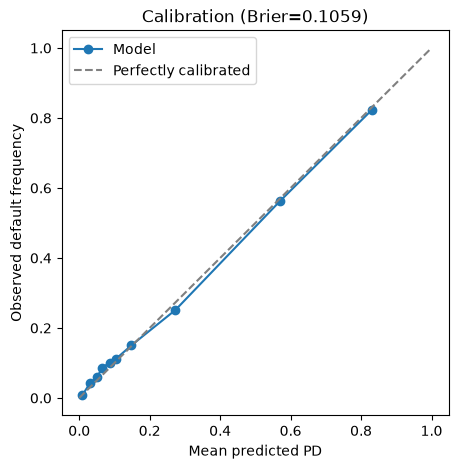

In [6]:
# Calibration curve for the deployed model
import matplotlib.pyplot as plt

pick = report['models'].get('logistic_calibrated') or report['models']['logistic_uncalibrated']
cal = pick['calibration_curve']
plt.figure(figsize=(5,5))
plt.plot(cal['mean_predicted'], cal['fraction_positive'], 'o-', label='Model')
plt.plot([0,1],[0,1],'--',color='grey', label='Perfectly calibrated')
plt.xlabel('Mean predicted PD'); plt.ylabel('Observed default frequency')
plt.title(f"Calibration (Brier={pick['brier_score']:.4f})"); plt.legend(); plt.show()

## 5. Expected Credit Loss (EL = PD × LGD × EAD)

In [7]:
from src.expected_loss import build_loss_table, portfolio_metrics
from src.risk_segmentation import add_risk_bands, segment_summary
from src import config

pd_hat = model.predict_pd(clean)
loss_table = add_risk_bands(build_loss_table(clean, pd_hat, lgd=config.DEFAULT_LGD))
pm = portfolio_metrics(loss_table)

print(f'LGD assumption      : {config.DEFAULT_LGD:.0%}')
print(f'Total EAD           : ${pm.total_ead:,.0f}')
print(f'Average PD (exp-wtd): {pm.average_pd:.2%}')
print(f'Total Expected Loss : ${pm.total_expected_loss:,.0f}')
print(f'Expected Loss rate  : {pm.expected_loss_rate:.2%}')
print(f'High-risk exposure  : ${pm.high_risk_exposure:,.0f} ({pm.high_risk_exposure_pct:.1%})')

LGD assumption      : 45%
Total EAD           : $312,320,100
Average PD (exp-wtd): 24.55%
Total Expected Loss : $34,498,131
Expected Loss rate  : 11.05%
High-risk exposure  : $122,158,575 (39.1%)


## 6. Risk segmentation

In [8]:
segment_summary(loss_table)[['risk_band','n_borrowers','total_ead','average_pd',
                             'expected_loss','exposure_pct']]

,risk_band,n_borrowers,total_ead,average_pd,expected_loss,exposure_pct
0,Low Risk,8162,"75,681,550.0000",0.0241,"790,126.2996",0.2423
1,Moderate Risk,13275,"114,479,975.0000",0.0871,"4,551,332.1692",0.3665
2,High Risk,3350,"34,413,525.0000",0.2054,"3,218,631.3580",0.1102
3,Very High Risk,7787,"87,745,050.0000",0.6472,"25,938,041.1150",0.2809


## 7. Stress testing (hypothetical sensitivity analysis)

In [9]:
from src.stress_testing import run_all_scenarios, scenario_comparison_table

results = run_all_scenarios(clean, model, lgd=config.DEFAULT_LGD)
scenario_comparison_table(results)[['scenario','average_pd','expected_loss',
                                    'expected_loss_rate','el_increase_vs_base',
                                    'pct_increase_vs_base']]

,scenario,average_pd,expected_loss,expected_loss_rate,el_increase_vs_base,pct_increase_vs_base
0,Base,0.2455,"34,498,130.9418",0.1105,0.0000,0.0000
1,Moderate,0.3451,"48,507,565.6727",0.1553,"14,009,434.7309",40.6093
2,Severe,0.5265,"73,992,504.3434",0.2369,"39,494,373.4015",114.4826


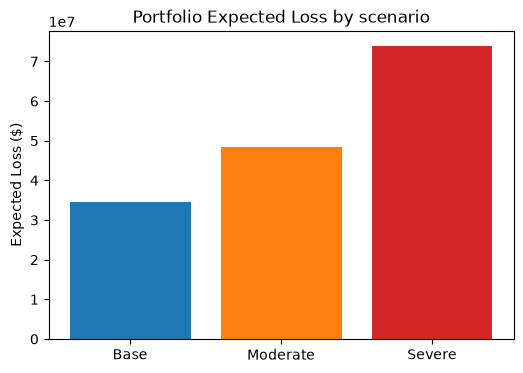

In [10]:
comp = scenario_comparison_table(results)
plt.figure(figsize=(6,4))
plt.bar(comp['scenario'], comp['expected_loss'], color=['#1f77b4','#ff7f0e','#d62728'])
plt.ylabel('Expected Loss ($)'); plt.title('Portfolio Expected Loss by scenario')
plt.show()

## Takeaways

- The logistic PD model ranks default risk well (ROC-AUC) and, after isotonic
  calibration, produces better-scaled probabilities (lower Brier) — important
  because PD drives every loss figure.
- Expected Loss concentrates in the high-PD bands and in the weaker loan grades.
- Under the hypothetical **Severe** scenario, portfolio Expected Loss increases
  materially versus the base case — this is a *sensitivity* result, not a forecast.

See the Streamlit dashboard (`streamlit run dashboard/app.py`) for the interactive
version, including borrower-level explainability and model diagnostics.